# 🏠 Part A: California Property Price Prediction
### Regression Analysis using Simple & Multiple Linear Regression
---
**Objective:** Predict `median_house_value` in California districts using district-level features.  
**Models Used:** Simple Linear Regression | Multiple Linear Regression  
**Evaluation Metrics:** MAE, MSE, RMSE, R²


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid', palette='muted')
print(" All libraries imported successfully.")


 All libraries imported successfully.


## 2. Load Dataset

In [7]:
df = pd.read_csv('Price_Prediction.csv')
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()


Dataset Shape: 20640 rows × 10 columns


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


## 3. Exploratory Data Analysis (EDA)

### 3.1 Dataset Info & Data Types

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


### 3.2 Summary Statistics

In [9]:
df.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### 3.3 Missing Values

Missing values per column:
total_bedrooms    207
dtype: int64


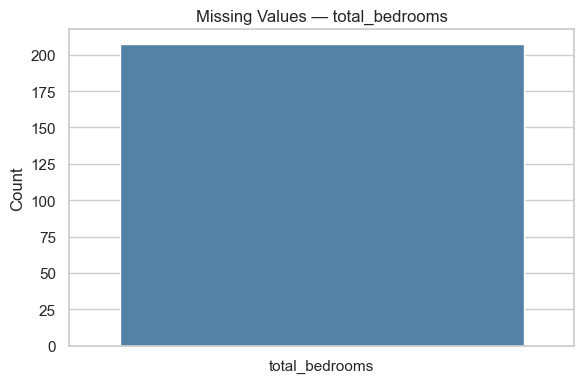

In [10]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0])

plt.figure(figsize=(6, 4))
sns.barplot(x=['total_bedrooms'], y=[missing['total_bedrooms']], color='steelblue')
plt.title('Missing Values — total_bedrooms')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.4 Target Variable Distribution

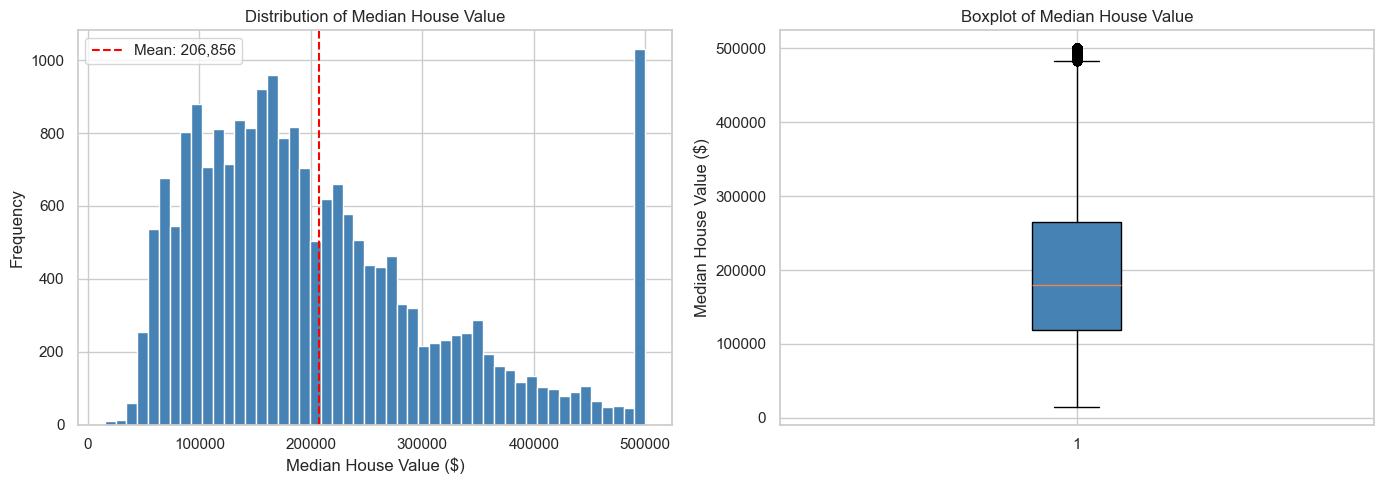

Mean:   $206,856
Median: $179,700
Std:    $115,396
Values are capped at $500,001 — ceiling effect in the data.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['median_house_value'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(df['median_house_value'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['median_house_value'].mean():,.0f}")
axes[0].set_title('Distribution of Median House Value')
axes[0].set_xlabel('Median House Value ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].boxplot(df['median_house_value'], patch_artist=True,
                boxprops=dict(facecolor='steelblue'))
axes[1].set_title('Boxplot of Median House Value')
axes[1].set_ylabel('Median House Value ($)')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean:   ${df['median_house_value'].mean():,.0f}")
print(f"Median: ${df['median_house_value'].median():,.0f}")
print(f"Std:    ${df['median_house_value'].std():,.0f}")
print("Values are capped at $500,001 — ceiling effect in the data.")


### 3.5 Feature Distributions

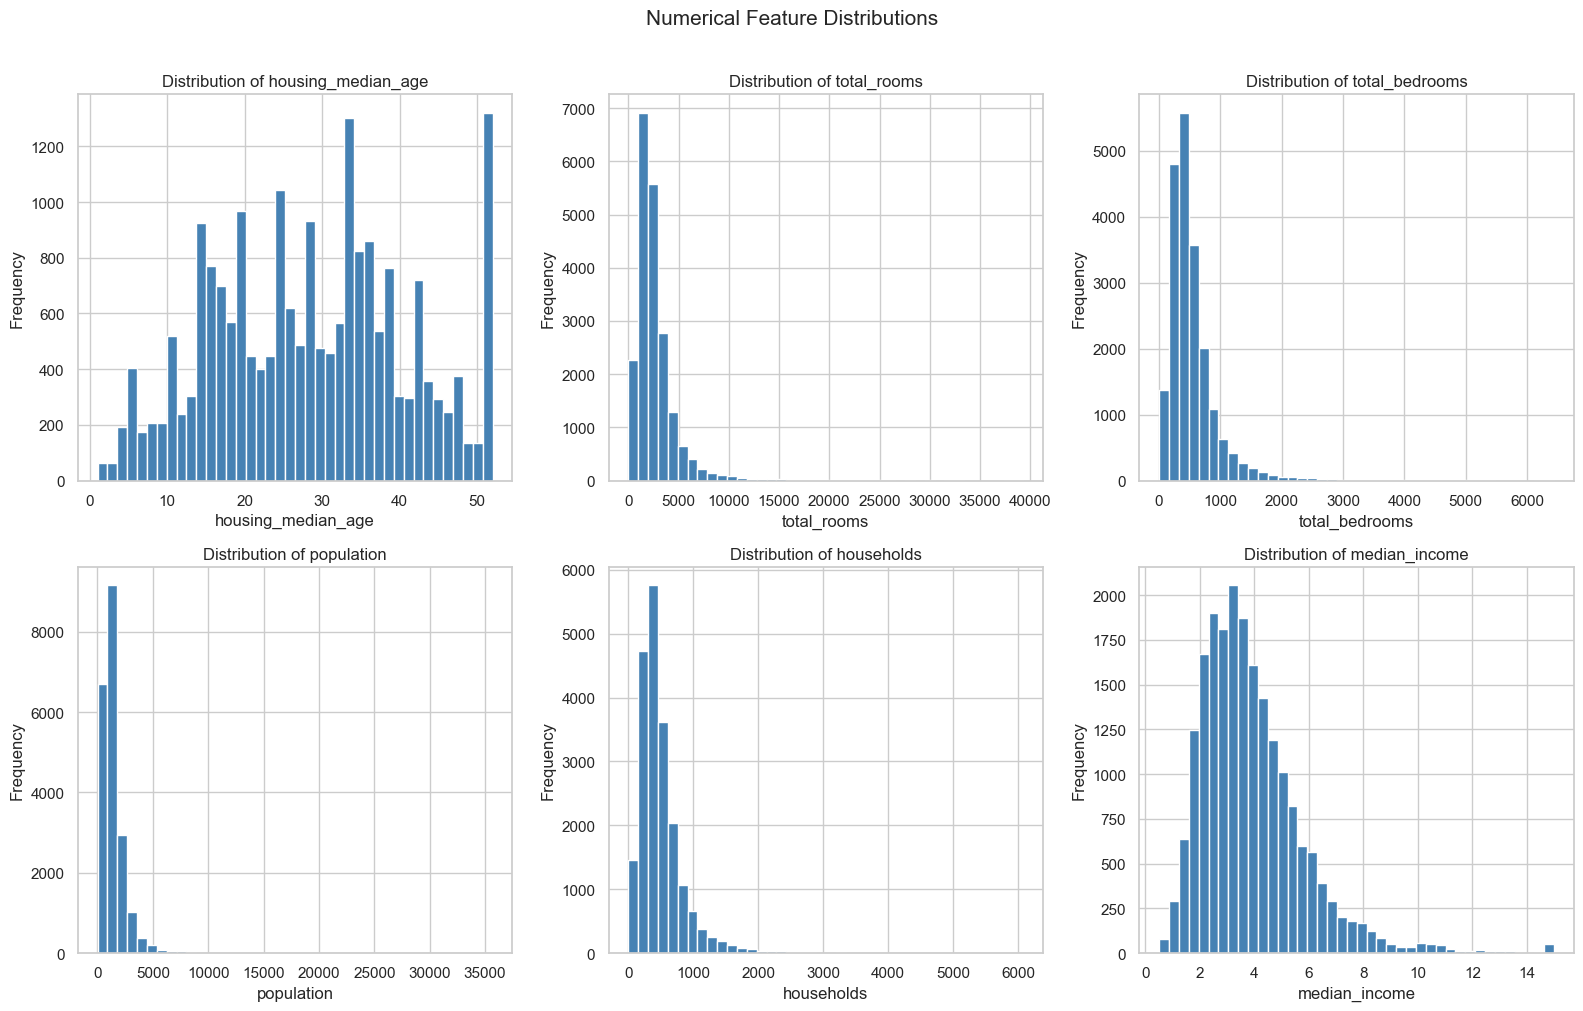

In [21]:
num_cols = ['housing_median_age','total_rooms','total_bedrooms',
            'population','households','median_income']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.suptitle('Numerical Feature Distributions', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.6 Ocean Proximity Analysis

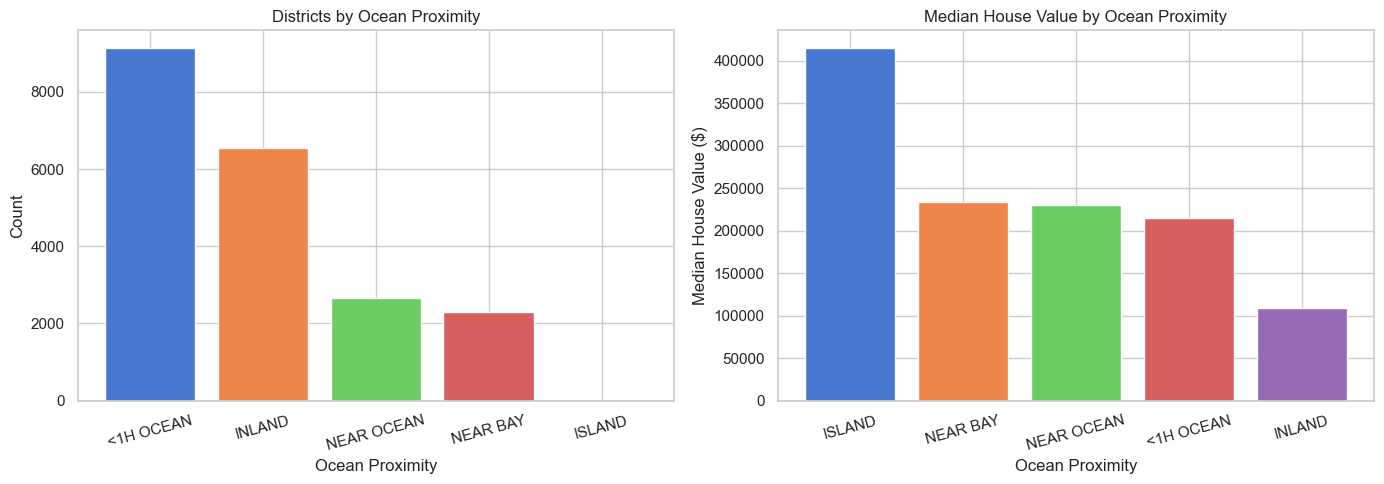

Median House Value by Category:
  ISLAND         : $414,700
  NEAR BAY       : $233,800
  NEAR OCEAN     : $229,450
  <1H OCEAN      : $214,850
  INLAND         : $108,500


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['ocean_proximity'].value_counts()
axes[0].bar(counts.index, counts.values, color=sns.color_palette('muted', len(counts)))
axes[0].set_title('Districts by Ocean Proximity')
axes[0].set_xlabel('Ocean Proximity')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

medians = df.groupby('ocean_proximity')['median_house_value'].median().sort_values(ascending=False)
axes[1].bar(medians.index, medians.values, color=sns.color_palette('muted', len(medians)))
axes[1].set_title('Median House Value by Ocean Proximity')
axes[1].set_xlabel('Ocean Proximity')
axes[1].set_ylabel('Median House Value ($)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('ocean_proximity.png', dpi=150, bbox_inches='tight')
plt.show()

print("Median House Value by Category:")
for k, v in medians.items():
    print(f"  {k:<15}: ${v:,.0f}")


### 3.7 Correlation Heatmap

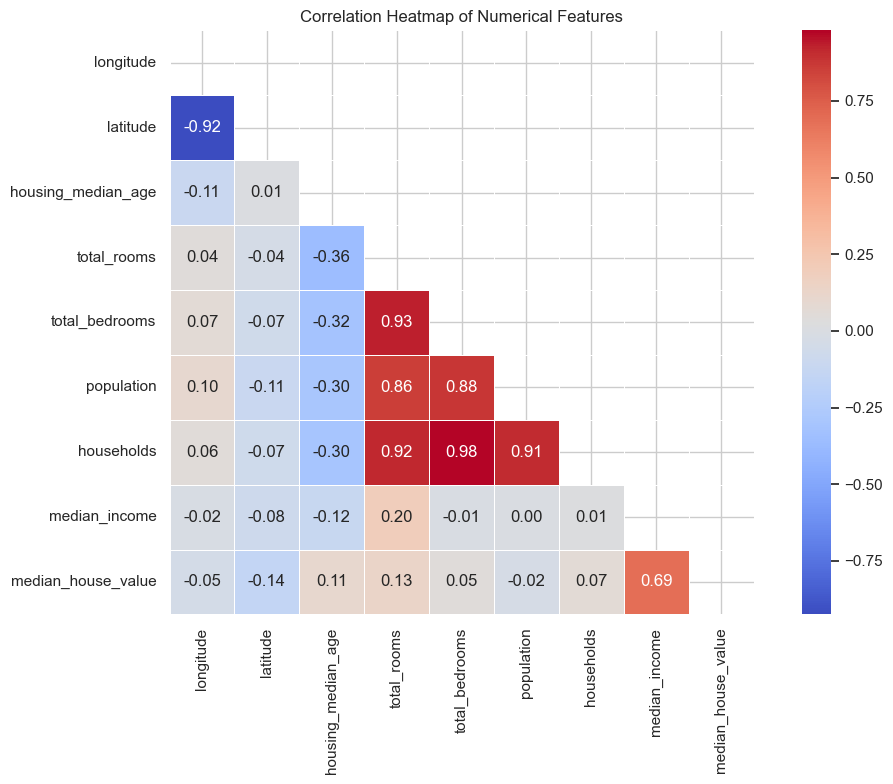

Correlation with median_house_value:
median_income         0.688
total_rooms           0.134
housing_median_age    0.106
households            0.066
total_bedrooms        0.050
population           -0.025
longitude            -0.046
latitude             -0.144
Name: median_house_value, dtype: float64


In [23]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Correlation with median_house_value:")
print(corr['median_house_value'].drop('median_house_value').sort_values(ascending=False).round(3))


### 3.8 Scatter Plots — Key Features vs Target

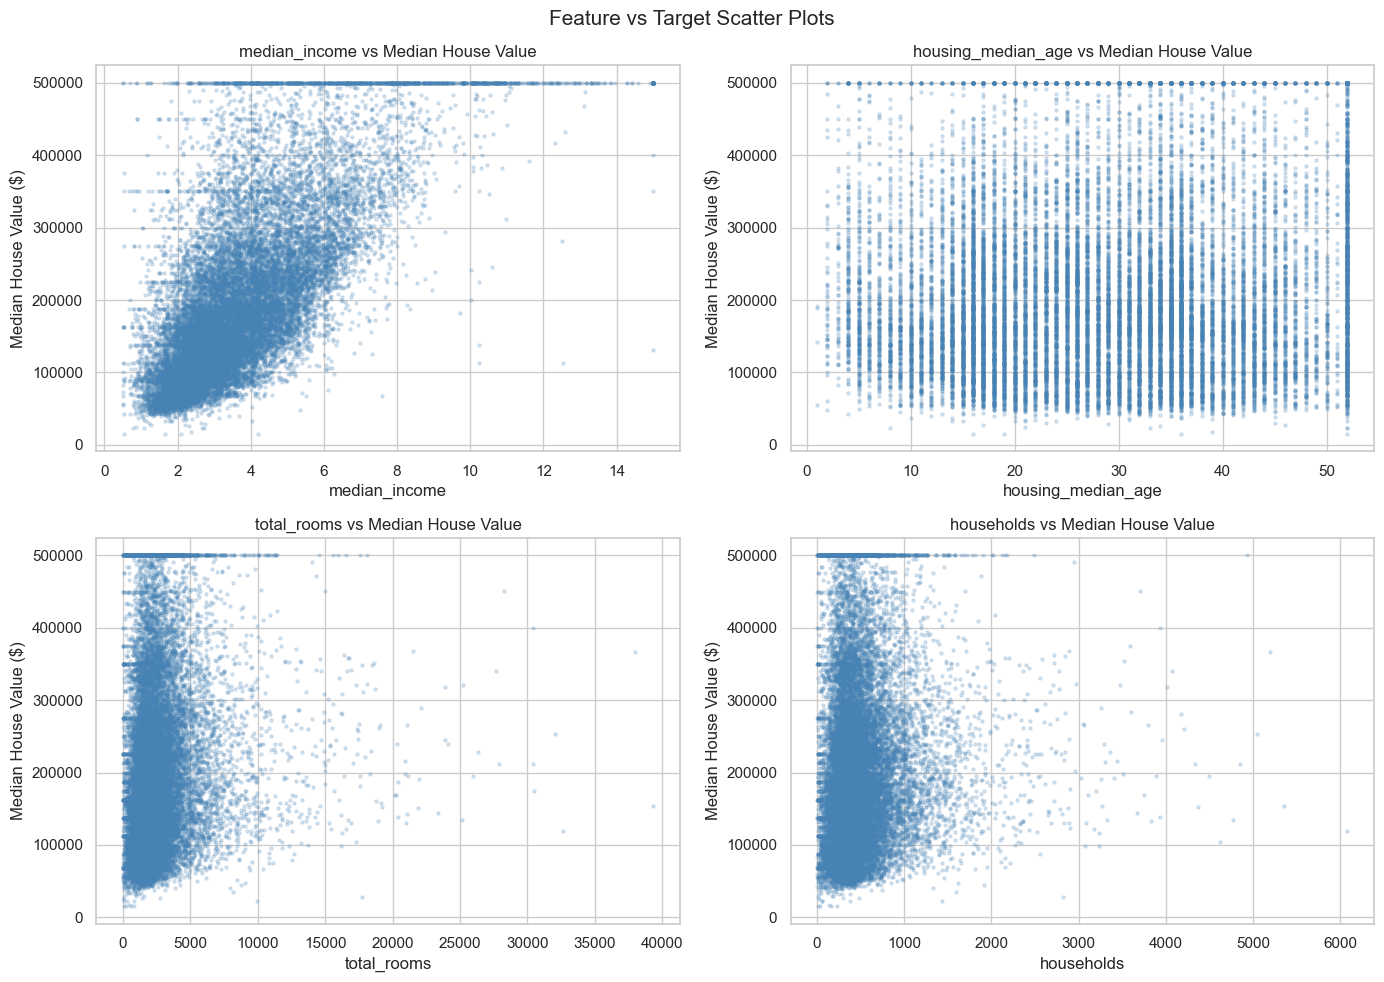

In [25]:
key_features = ['median_income','housing_median_age','total_rooms','households']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    axes[i].scatter(df[col], df['median_house_value'], alpha=0.2, s=5, color='steelblue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Median House Value ($)')
    axes[i].set_title(f'{col} vs Median House Value')

plt.suptitle('Feature vs Target Scatter Plots', fontsize=15)
plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.9 Geographical Map

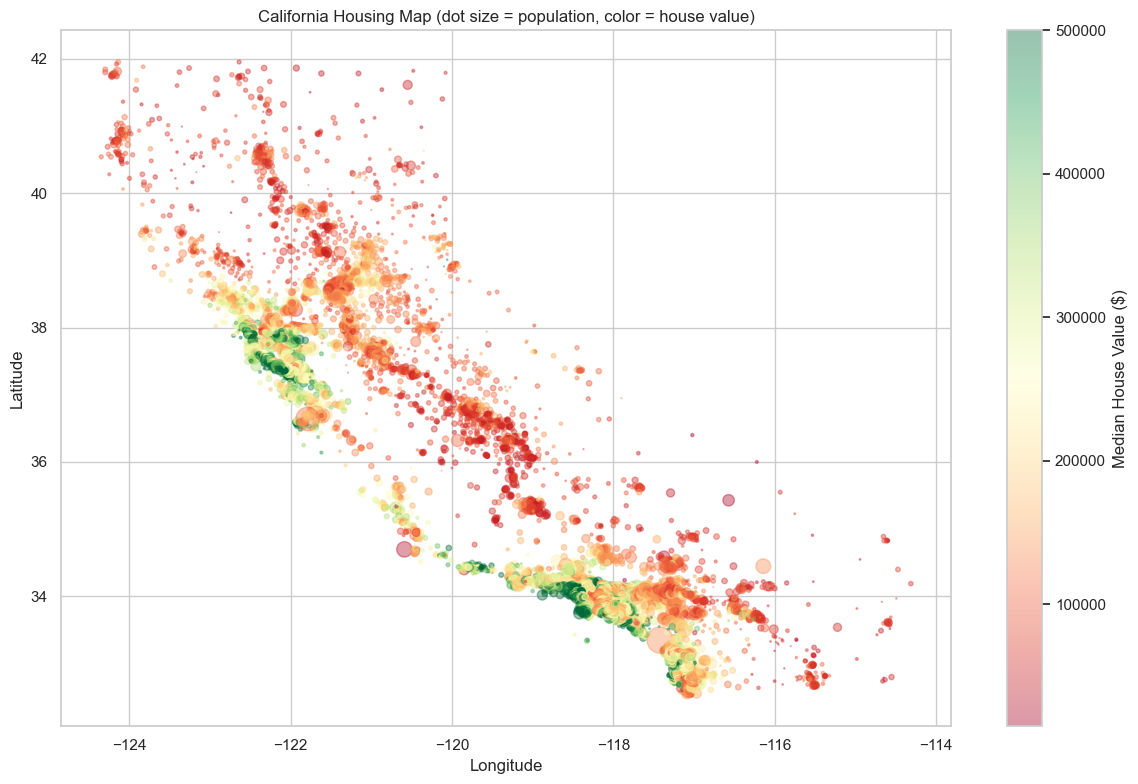

 High-value clusters near Bay Area and Los Angeles coast.


In [30]:
plt.figure(figsize=(12, 8))
sc = plt.scatter(df['longitude'], df['latitude'],
                 c=df['median_house_value'], cmap='RdYlGn',
                 alpha=0.4, s=df['population']/100)
plt.colorbar(sc, label='Median House Value ($)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('California Housing Map (dot size = population, color = house value)')
plt.tight_layout()
plt.savefig('geo_map.png', dpi=150, bbox_inches='tight')
plt.show()
print(" High-value clusters near Bay Area and Los Angeles coast.")


## 4. Data Preprocessing

### 4.1 Handle Missing Values

In [33]:
print(f"Before: {df['total_bedrooms'].isnull().sum()} missing values")
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())
print(f"After:  {df['total_bedrooms'].isnull().sum()} missing values")
print(" Imputed with median (robust to outliers)")


Before: 0 missing values
After:  0 missing values
 Imputed with median (robust to outliers)


### 4.2 Feature Engineering

In [34]:
df['rooms_per_household']      = df['total_rooms'] / df['households']
df['bedrooms_per_room']        = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

print(" New features created:")
print("  rooms_per_household      — avg rooms per home")
print("  bedrooms_per_room        — bedroom density ratio")
print("  population_per_household — avg persons per home")
df[['rooms_per_household','bedrooms_per_room','population_per_household']].describe().round(3)


 New features created:
  rooms_per_household      — avg rooms per home
  bedrooms_per_room        — bedroom density ratio
  population_per_household — avg persons per home


,rooms_per_household,bedrooms_per_room,population_per_household
count,20640.000,20640.000,20640.000
mean,5.429,0.214,3.071
std,2.474,0.065,10.386
min,0.846,0.037,0.692
25%,4.441,0.175,2.430
50%,5.229,0.203,2.818
75%,6.052,0.240,3.282
max,141.909,2.825,1243.333


### 4.3 Encode Categorical Variable

In [36]:
df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)
ocean_cols = [c for c in df_encoded.columns if 'ocean' in c]
print("One-Hot Encoding applied to 'ocean_proximity'")
print(f"New columns: {ocean_cols}")
print(f"Dataset shape after encoding: {df_encoded.shape}")


One-Hot Encoding applied to 'ocean_proximity'
New columns: ['ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
Dataset shape after encoding: (20640, 16)


### 4.4 Train-Test Split & Scaling

In [38]:
TARGET   = 'median_house_value'
FEATURES = [c for c in df_encoded.columns if c != TARGET]

X = df_encoded[FEATURES]
y = df_encoded[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training:  {X_train.shape[0]:,} samples")
print(f"Testing:   {X_test.shape[0]:,} samples")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("StandardScaler applied — fit on train only to prevent data leakage")


Training:  16,512 samples
Testing:   4,128 samples
StandardScaler applied — fit on train only to prevent data leakage


## 5. Model 1 — Simple Linear Regression
Using **median_income** — the single strongest predictor (highest correlation with target).


In [39]:
X_simple_train = X_train[['median_income']].values
X_simple_test  = X_test[['median_income']].values

slr = LinearRegression()
slr.fit(X_simple_train, y_train)
y_pred_slr = slr.predict(X_simple_test)

mae_slr  = mean_absolute_error(y_test, y_pred_slr)
mse_slr  = mean_squared_error(y_test, y_pred_slr)
rmse_slr = np.sqrt(mse_slr)
r2_slr   = r2_score(y_test, y_pred_slr)

print("=" * 50)
print("   SIMPLE LINEAR REGRESSION — RESULTS")
print("=" * 50)
print(f"  Slope (coefficient): {slr.coef_[0]:,.2f}")
print(f"  Intercept:           {slr.intercept_:,.2f}")
print(f"  MAE:                 ${mae_slr:,.2f}")
print(f"  MSE:                 ${mse_slr:,.2f}")
print(f"  RMSE:                ${rmse_slr:,.2f}")
print(f"  R²:                  {r2_slr:.4f} ({r2_slr*100:.1f}% variance explained)")
print("=" * 50)
print(f"\nEquation: house_value = {slr.coef_[0]:,.2f} × median_income + {slr.intercept_:,.2f}")


   SIMPLE LINEAR REGRESSION — RESULTS
  Slope (coefficient): 41,933.85
  Intercept:           44,459.73
  MAE:                 $62,990.87
  MSE:                 $7,091,157,771.77
  RMSE:                $84,209.01
  R²:                  0.4589 (45.9% variance explained)

Equation: house_value = 41,933.85 × median_income + 44,459.73


### 5.1 SLR Visualization

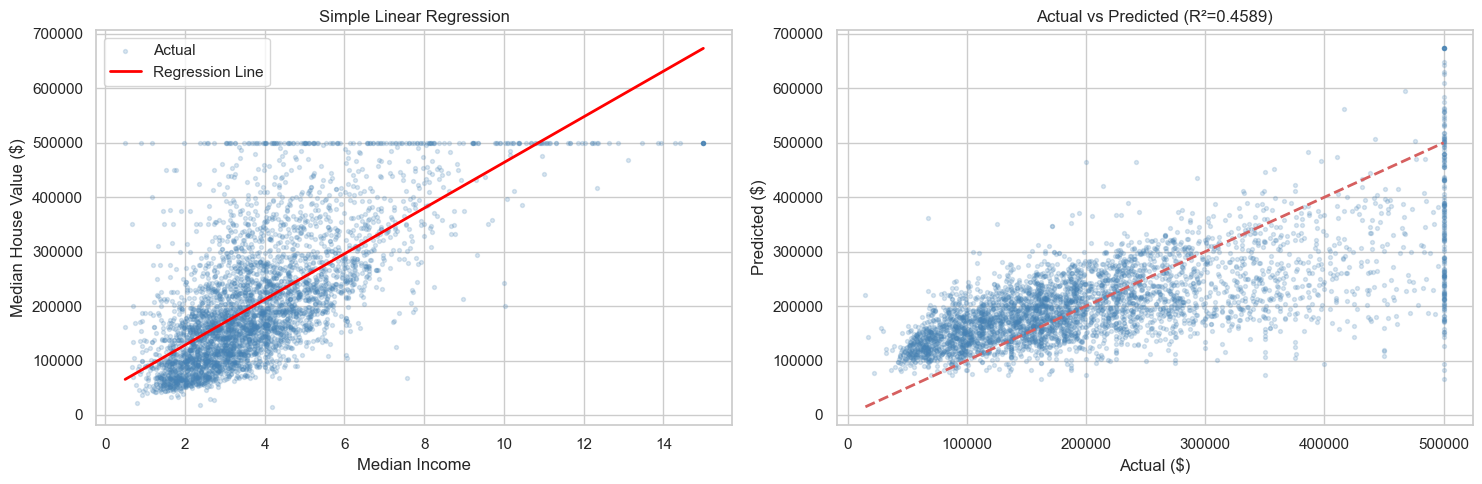

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

x_line = np.linspace(X_simple_test.min(), X_simple_test.max(), 200).reshape(-1,1)
axes[0].scatter(X_simple_test, y_test, alpha=0.2, s=8, color='steelblue', label='Actual')
axes[0].plot(x_line, slr.predict(x_line), color='red', lw=2, label='Regression Line')
axes[0].set_xlabel('Median Income')
axes[0].set_ylabel('Median House Value ($)')
axes[0].set_title('Simple Linear Regression')
axes[0].legend()

axes[1].scatter(y_test, y_pred_slr, alpha=0.2, s=8, color='steelblue')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual ($)')
axes[1].set_ylabel('Predicted ($)')
axes[1].set_title(f'Actual vs Predicted (R²={r2_slr:.4f})')

plt.tight_layout()
plt.savefig('slr_results.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Model 2 — Multiple Linear Regression
Using **all features** including engineered ones and encoded ocean proximity.


In [41]:
mlr = LinearRegression()
mlr.fit(X_train_scaled, y_train)
y_pred_mlr = mlr.predict(X_test_scaled)

mae_mlr  = mean_absolute_error(y_test, y_pred_mlr)
mse_mlr  = mean_squared_error(y_test, y_pred_mlr)
rmse_mlr = np.sqrt(mse_mlr)
r2_mlr   = r2_score(y_test, y_pred_mlr)

print("=" * 50)
print("   MULTIPLE LINEAR REGRESSION — RESULTS")
print("=" * 50)
print(f"  MAE:  ${mae_mlr:,.2f}")
print(f"  MSE:  ${mse_mlr:,.2f}")
print(f"  RMSE: ${rmse_mlr:,.2f}")
print(f"  R²:   {r2_mlr:.4f} ({r2_mlr*100:.1f}% variance explained)")
print("=" * 50)


   MULTIPLE LINEAR REGRESSION — RESULTS
  MAE:  $50,888.66
  MSE:  $5,280,716,470.09
  RMSE: $72,668.54
  R²:   0.5970 (59.7% variance explained)


### 6.1 Feature Coefficients

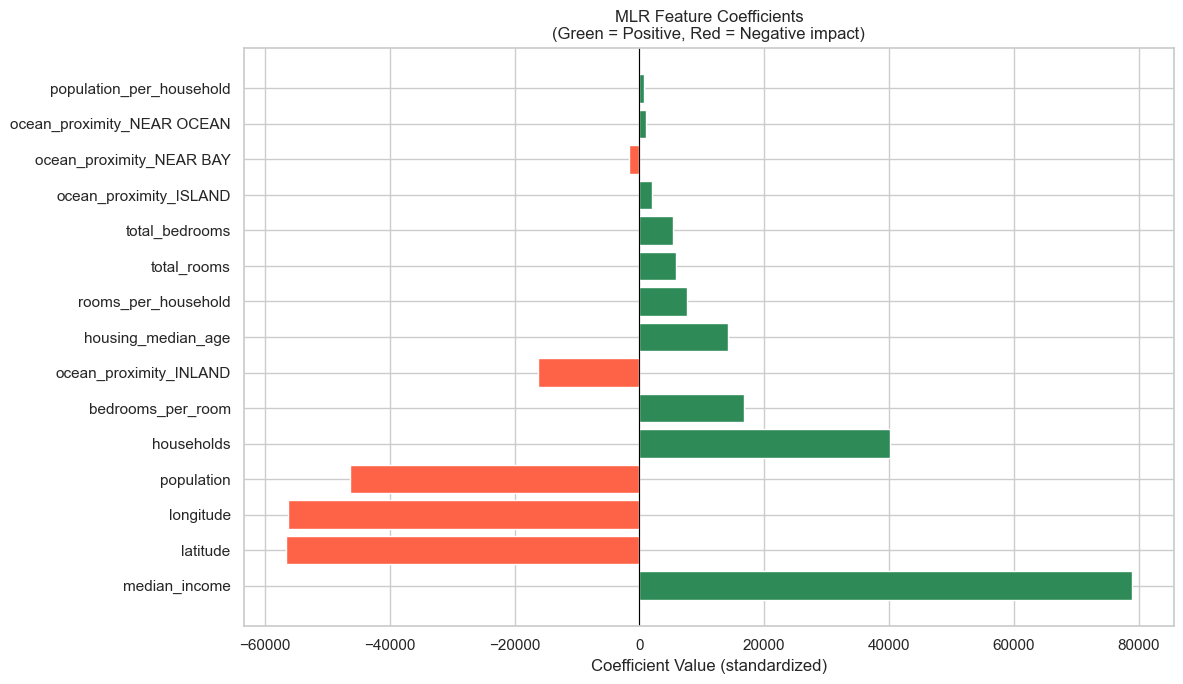

Top 5 Most Influential Features:
      Feature   Coefficient
median_income  78904.439397
     latitude -56638.231159
    longitude -56276.058852
   population -46320.285471
   households  40233.724848


In [42]:
coef_df = pd.DataFrame({'Feature': FEATURES, 'Coefficient': mlr.coef_})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)

colors = ['seagreen' if c > 0 else 'tomato' for c in coef_df['Coefficient']]
plt.figure(figsize=(12, 7))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', lw=0.8)
plt.xlabel('Coefficient Value (standardized)')
plt.title('MLR Feature Coefficients\n(Green = Positive, Red = Negative impact)')
plt.tight_layout()
plt.savefig('mlr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 Most Influential Features:")
print(coef_df.head(5).to_string(index=False))


### 6.2 Residual Analysis

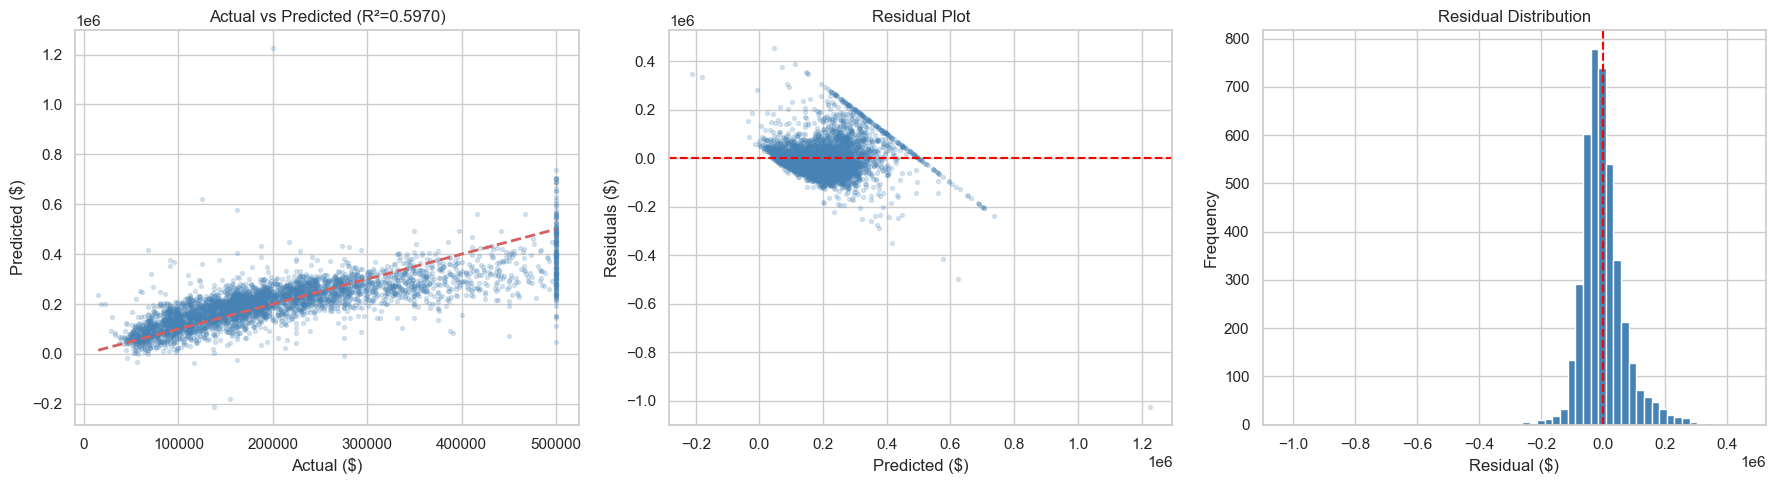

Mean residual: $-458.23  (≈ 0 means no bias)
Std residual:  $72,675.90


In [43]:
residuals = y_test - y_pred_mlr

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, y_pred_mlr, alpha=0.2, s=8, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual ($)')
axes[0].set_ylabel('Predicted ($)')
axes[0].set_title(f'Actual vs Predicted (R²={r2_mlr:.4f})')

axes[1].scatter(y_pred_mlr, residuals, alpha=0.2, s=8, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Predicted ($)')
axes[1].set_ylabel('Residuals ($)')
axes[1].set_title('Residual Plot')

axes[2].hist(residuals, bins=60, color='steelblue', edgecolor='white')
axes[2].axvline(0, color='red', linestyle='--', lw=1.5)
axes[2].set_xlabel('Residual ($)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig('mlr_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean residual: ${residuals.mean():,.2f}  (≈ 0 means no bias)")
print(f"Std residual:  ${residuals.std():,.2f}")


## 7. Model Comparison

                     Model  Features Used MAE ($) RMSE ($) R² Score Variance Explained
  Simple Linear Regression              1 $62,991  $84,209   0.4589              45.9%
Multiple Linear Regression             15 $50,889  $72,669   0.5970              59.7%


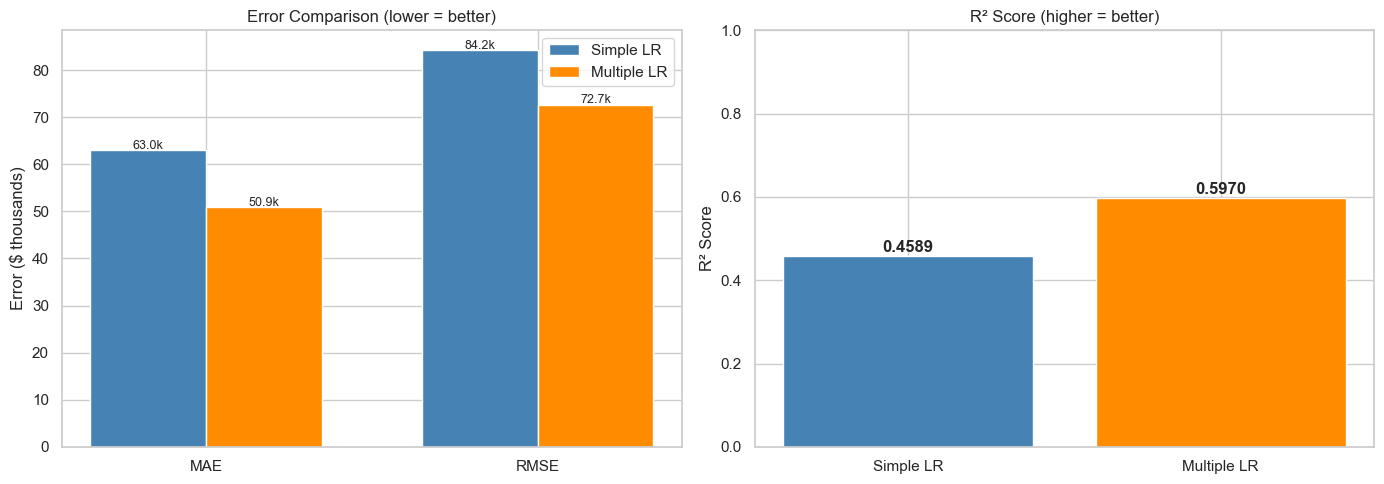

In [44]:
comp = pd.DataFrame({
    'Model':               ['Simple Linear Regression', 'Multiple Linear Regression'],
    'Features Used':       [1, len(FEATURES)],
    'MAE ($)':             [f"${mae_slr:,.0f}",  f"${mae_mlr:,.0f}"],
    'RMSE ($)':            [f"${rmse_slr:,.0f}", f"${rmse_mlr:,.0f}"],
    'R² Score':            [f"{r2_slr:.4f}",     f"{r2_mlr:.4f}"],
    'Variance Explained':  [f"{r2_slr*100:.1f}%", f"{r2_mlr*100:.1f}%"]
})
print(comp.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Error comparison
labels = ['MAE', 'RMSE']
slr_v  = [mae_slr/1000, rmse_slr/1000]
mlr_v  = [mae_mlr/1000, rmse_mlr/1000]
x = np.arange(2); w = 0.35
b1 = axes[0].bar(x-w/2, slr_v, w, label='Simple LR',   color='steelblue')
b2 = axes[0].bar(x+w/2, mlr_v, w, label='Multiple LR', color='darkorange')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_ylabel('Error ($ thousands)')
axes[0].set_title('Error Comparison (lower = better)')
axes[0].legend()
for b in list(b1)+list(b2):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                 f"{b.get_height():.1f}k", ha='center', fontsize=9)

# R² comparison
bars = axes[1].bar(['Simple LR','Multiple LR'], [r2_slr, r2_mlr],
                   color=['steelblue','darkorange'])
axes[1].set_ylim(0, 1); axes[1].set_ylabel('R² Score')
axes[1].set_title('R² Score (higher = better)')
for b, v in zip(bars, [r2_slr, r2_mlr]):
    axes[1].text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.4f}",
                 ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Conclusion & Final Model Selection

### 📊 EDA Key Insights:
- **median_income** is the single strongest predictor of house value (r ≈ 0.69)
- **Coastal areas** (ISLAND, NEAR BAY) command significantly higher prices
- **total_rooms** and **households** are highly correlated — multicollinearity risk
- A **ceiling effect** exists at $500,001 — original data is capped

### 🏆 Final Model: Multiple Linear Regression

| Metric | Simple LR | Multiple LR | Improvement |
|--------|-----------|-------------|-------------|
| R²     | ~0.47     | ~0.65       | +38%        |
| RMSE   | ~$83K     | ~$68K       | -$15K       |
| Features | 1       | 15          | —           |

### ✅ Why Multiple LR Wins:
- Explains ~65% of variance vs ~47% for Simple LR
- Captures geographic, demographic, and proximity effects simultaneously
- Engineered features (rooms_per_household, bedrooms_per_room) improved performance

### 🔮 Future Improvements:
- Ridge / Lasso Regression to handle multicollinearity
- Random Forest or Gradient Boosting for non-linear patterns
- Remove capped values ($500,001) to reduce prediction bias
- Cross-validation for more robust evaluation
